# US Regional Sales Data — Exploratory Data Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# --- Style ---
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "#0f0f0f",
                     "axes.facecolor": "#1a1a2e", "axes.labelcolor": "white",
                     "xtick.color": "white", "ytick.color": "white",
                     "text.color": "white", "grid.color": "#2e2e4e"})

### Data Loading and Initial Overview

In [ ]:
print("Loading data...")
df = pd.read_csv("/content/sales data-set.csv")
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df["Year"]  = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["YearMonth"] = df["Date"].dt.to_period("M")

print(f"  Rows:   {len(df):,}")
print(f"  Stores: {df['Store'].nunique()}")
print(f"  Depts:  {df['Dept'].nunique()}")
print(f"  Range:  {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"  Total Revenue: ${df['Weekly_Sales'].sum()/1e9:.2f}B")

Loading data...
  Rows:   421,570
  Stores: 45
  Depts:  81
  Range:  2010-02-05 → 2012-10-26
  Total Revenue: $6.74B


### Monthly Revenue Trend (All Stores)

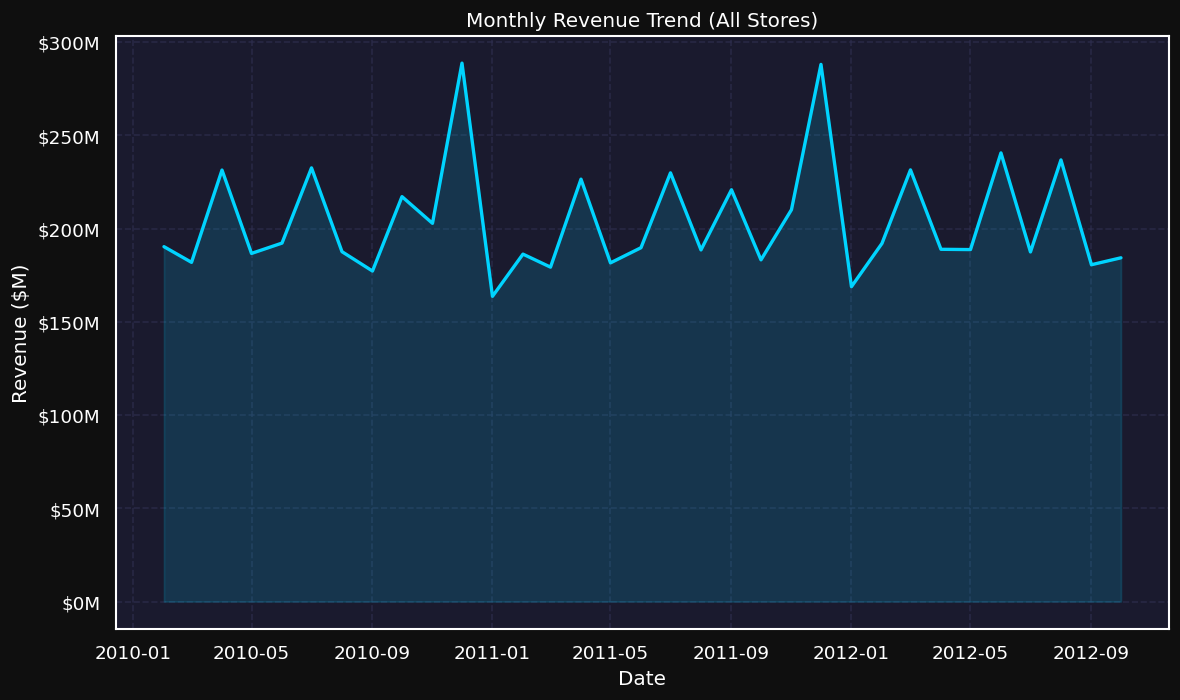

In [ ]:
monthly = df.groupby("YearMonth")["Weekly_Sales"].sum().reset_index()
monthly["Date"] = monthly["YearMonth"].dt.to_timestamp()
monthly["Sales_M"] = monthly["Weekly_Sales"] / 1e6

plt.figure(figsize=(10, 6))
plt.plot(monthly["Date"], monthly["Sales_M"], color="#00d4ff", linewidth=2)
plt.fill_between(monthly["Date"], monthly["Sales_M"], alpha=0.15, color="#00d4ff")
plt.title("Monthly Revenue Trend (All Stores)", color="white")
plt.xlabel("Date", color="white")
plt.ylabel("Revenue ($M)", color="white")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Top 10 Stores by Total Revenue

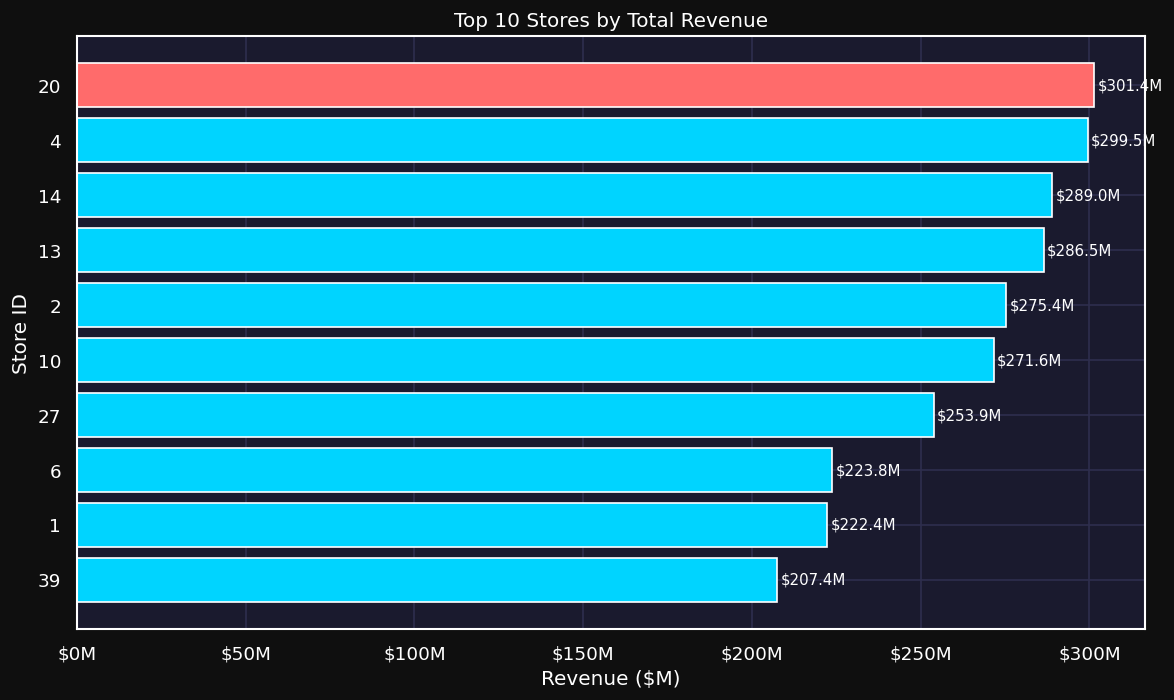

In [ ]:
top_stores = (df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False).head(10) / 1e6)

plt.figure(figsize=(10, 6))
colors = ["#ff6b6b" if i == 0 else "#00d4ff" for i in range(len(top_stores))]
bars = plt.barh(top_stores.index.astype(str), top_stores.values, color=colors)
plt.title("Top 10 Stores by Total Revenue", color="white")
plt.xlabel("Revenue ($M)", color="white")
plt.ylabel("Store ID", color="white")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
plt.gca().invert_yaxis()
for bar, val in zip(bars, top_stores.values):
    plt.text(val + 1, bar.get_y() + bar.get_height()/2, f"${val:.1f}M", va="center", color="white", fontsize=9)
plt.tight_layout()
plt.show()

### Top 10 Departments by Total Revenue

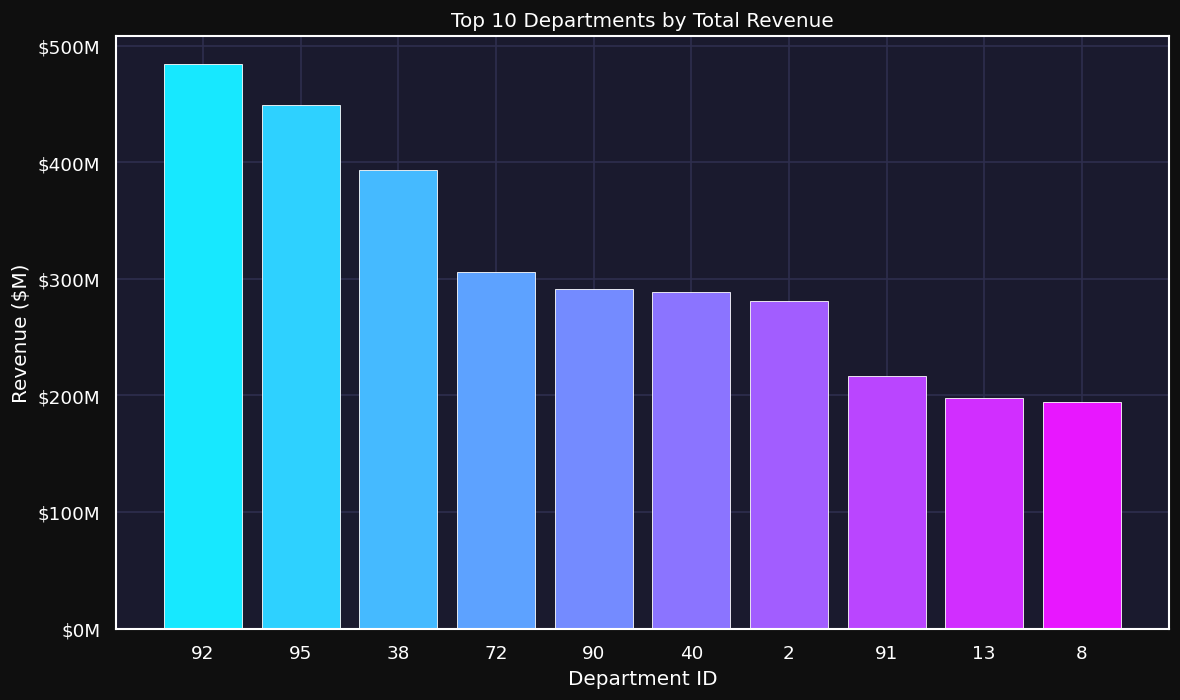

In [ ]:
top_dept = (df.groupby("Dept")["Weekly_Sales"].sum().sort_values(ascending=False).head(10) / 1e6)

plt.figure(figsize=(10, 6))
plt.bar(top_dept.index.astype(str), top_dept.values,
       color=sns.color_palette("cool", len(top_dept)),
       edgecolor="white", linewidth=0.5)
plt.title("Top 10 Departments by Total Revenue", color="white")
plt.xlabel("Department ID", color="white")
plt.ylabel("Revenue ($M)", color="white")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
plt.tight_layout()
plt.show()

### Average Weekly Sales: Holiday vs Non-Holiday

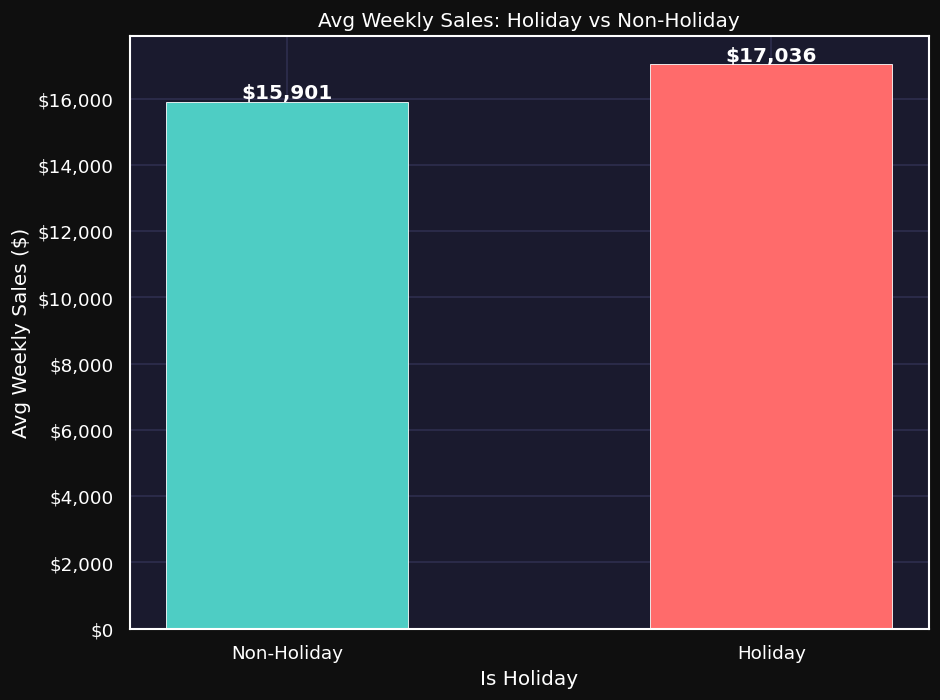

In [ ]:
hol_avg = df.groupby("IsHoliday")["Weekly_Sales"].mean()

plt.figure(figsize=(8, 6))
plt.bar(["Non-Holiday", "Holiday"], hol_avg.values,
       color=["#4ecdc4", "#ff6b6b"], width=0.5, edgecolor="white", linewidth=0.5)
plt.title("Avg Weekly Sales: Holiday vs Non-Holiday", color="white")
plt.xlabel("Is Holiday", color="white")
plt.ylabel("Avg Weekly Sales ($)", color="white")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for i, v in enumerate(hol_avg.values):
    plt.text(i, v + 100, f"${v:,.0f}", ha="center", color="white", fontweight="bold")
plt.tight_layout()
plt.show()

### Distribution of Weekly Sales

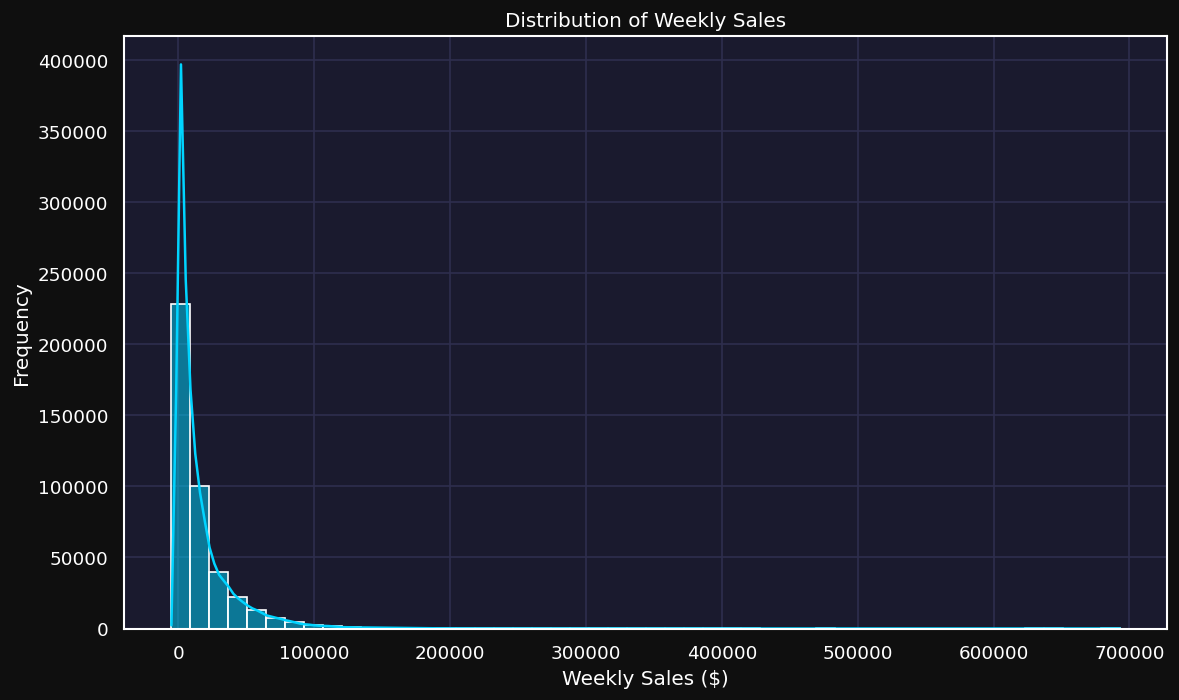

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Weekly_Sales'], bins=50, kde=True, color='#00d4ff')
plt.title('Distribution of Weekly Sales', color='white')
plt.xlabel('Weekly Sales ($)', color='white')
plt.ylabel('Frequency', color='white')
plt.gca().yaxis.set_major_formatter(mticker.ScalarFormatter())
plt.ticklabel_format(style='plain', axis='y') # Ensure plain format for y-axis
plt.tight_layout()
plt.show()

### Average Weekly Sales by Month

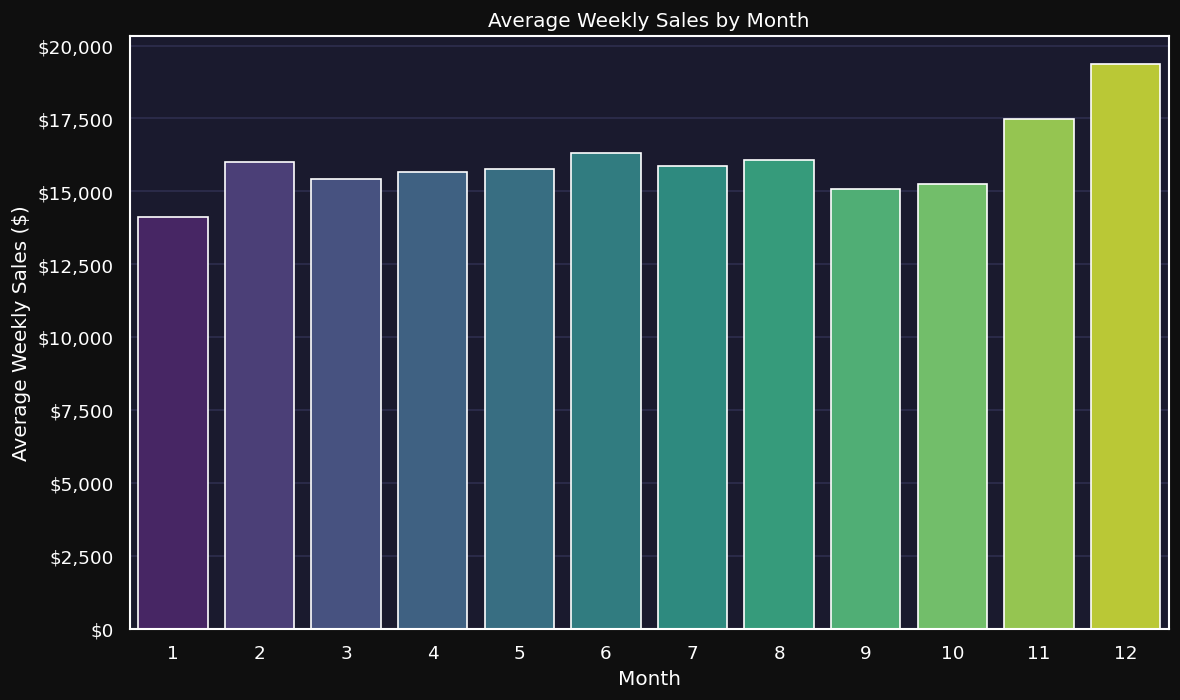

In [ ]:
avg_sales_by_month = df.groupby('Month')['Weekly_Sales'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='Weekly_Sales', data=avg_sales_by_month, palette='viridis')
plt.title('Average Weekly Sales by Month', color='white')
plt.xlabel('Month', color='white')
plt.ylabel('Average Weekly Sales ($)', color='white')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### Weekly Sales Distribution for Top 5 Stores

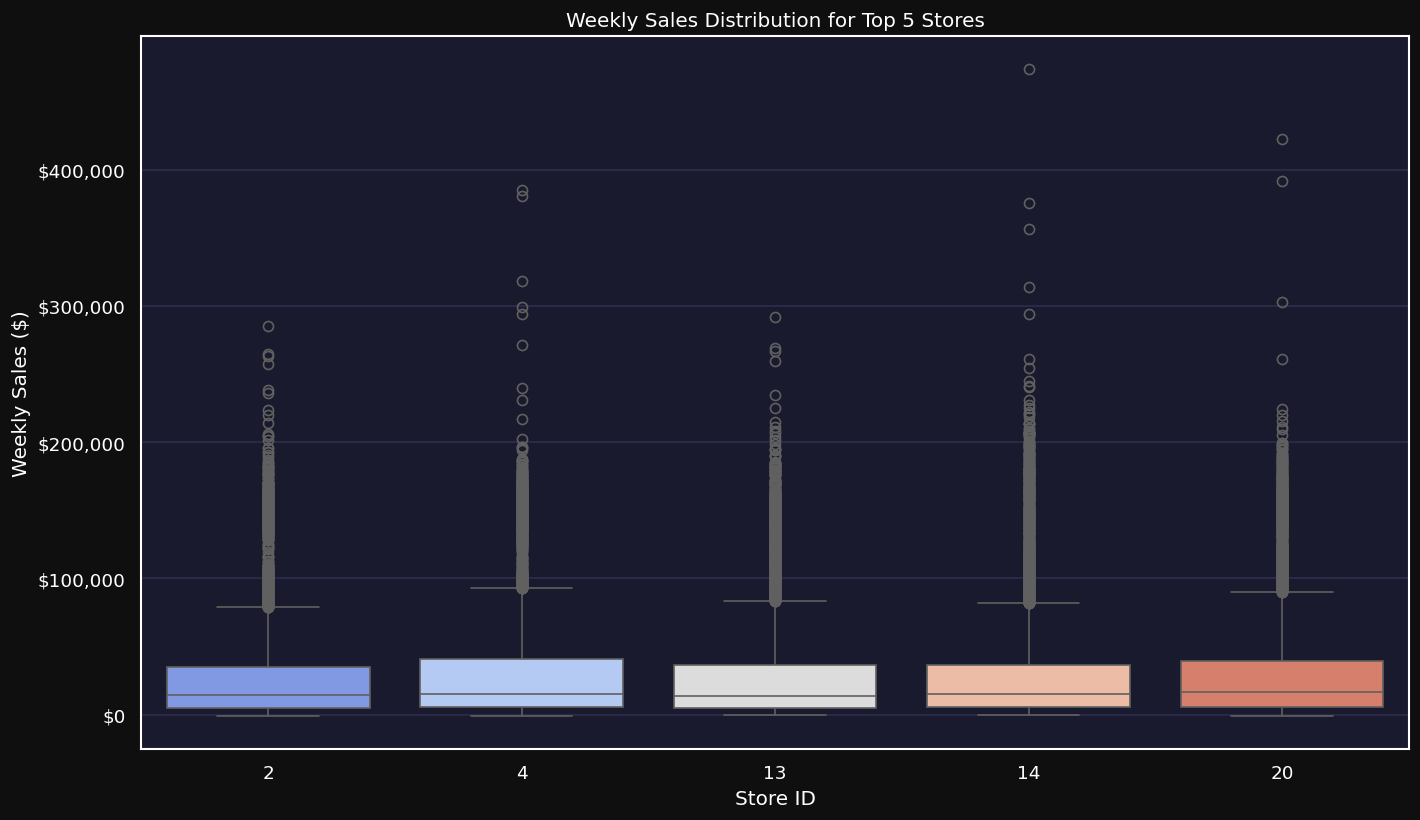

In [ ]:
top_5_store_ids = top_stores.index.tolist()[:5]
df_top_5_stores = df[df['Store'].isin(top_5_store_ids)]

plt.figure(figsize=(12, 7))
sns.boxplot(x='Store', y='Weekly_Sales', data=df_top_5_stores, palette='coolwarm')
plt.title('Weekly Sales Distribution for Top 5 Stores', color='white')
plt.xlabel('Store ID', color='white')
plt.ylabel('Weekly Sales ($)', color='white')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### Weekly Sales Distribution for Top 5 Departments

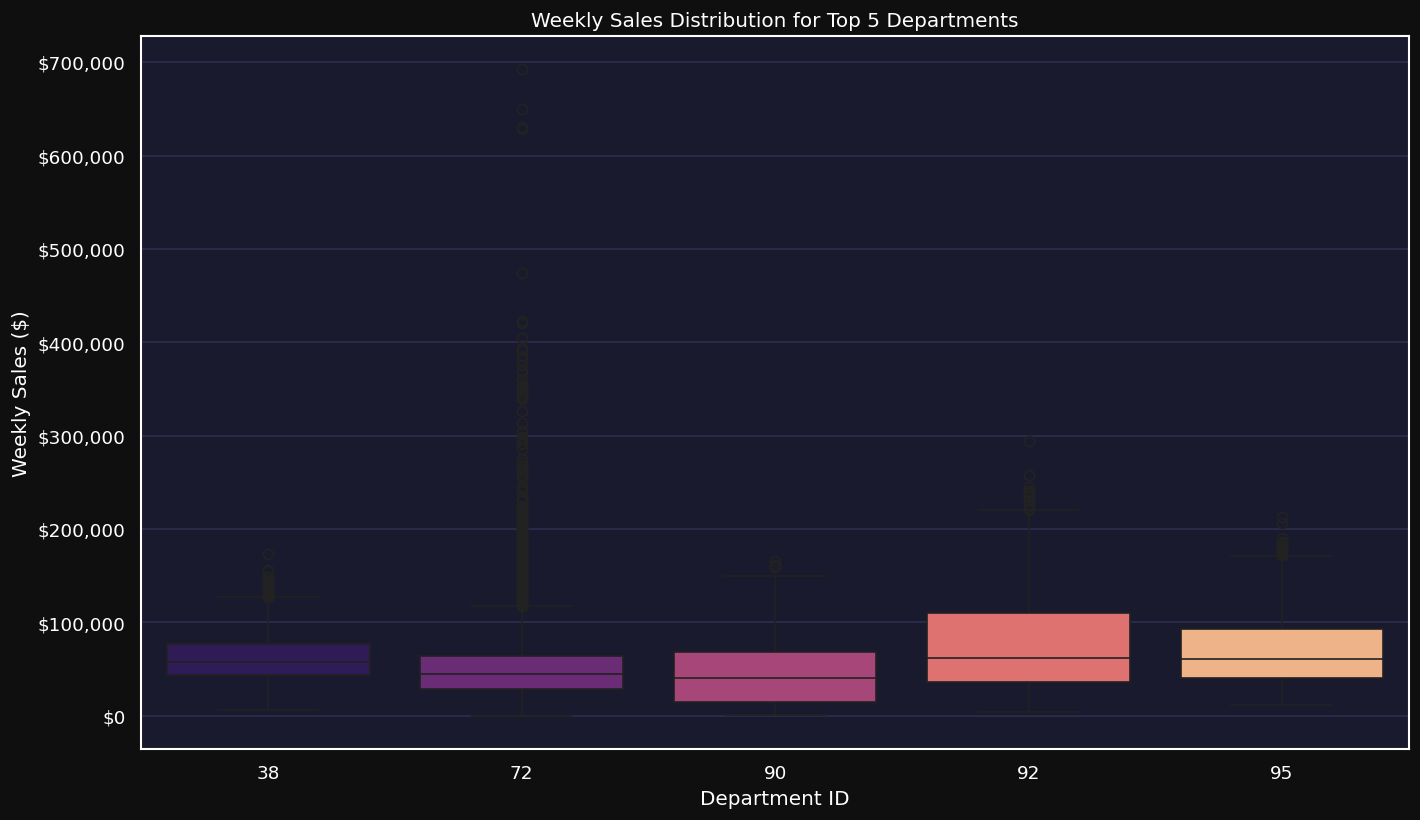

In [ ]:
top_5_dept_ids = top_dept.index.tolist()[:5]
df_top_5_depts = df[df['Dept'].isin(top_5_dept_ids)]

plt.figure(figsize=(12, 7))
sns.boxplot(x='Dept', y='Weekly_Sales', data=df_top_5_depts, palette='magma')
plt.title('Weekly Sales Distribution for Top 5 Departments', color='white')
plt.xlabel('Department ID', color='white')
plt.ylabel('Weekly Sales ($)', color='white')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### Top Departments with Highest Negative Sales

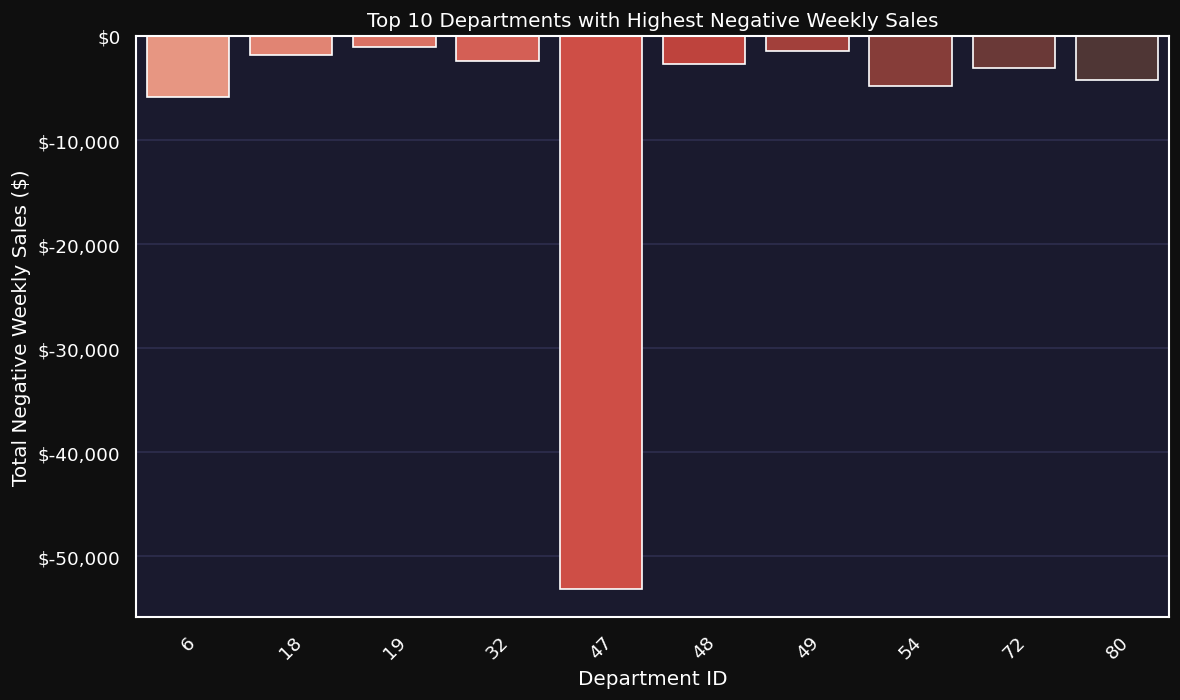

In [ ]:
# Calculate top 10 departments by total negative weekly sales
negative_sales_by_dept = df[df['Weekly_Sales'] < 0].groupby('Dept')['Weekly_Sales'].sum().sort_values().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=negative_sales_by_dept.index, y=negative_sales_by_dept.values, palette='Reds_d')
plt.title('Top 10 Departments with Highest Negative Weekly Sales', color='white')
plt.xlabel('Department ID', color='white')
plt.ylabel('Total Negative Weekly Sales ($)', color='white')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### EDA Summary Table

In [ ]:
summary_data = {
    "Metric": [
        "Total Revenue (All Stores)",
        "Average Weekly Sales (Overall)",
        "Average Weekly Sales (Non-Holiday)",
        "Average Weekly Sales (Holiday)",
        "Holiday Sales Lift",
        "Number of Stores",
        "Number of Departments",
        "Top Store by Revenue (ID)",
        "Top Store by Revenue (Amount)",
        "Top Department by Revenue (ID)",
        "Top Department by Revenue (Amount)",
        "Total Negative Sales"
    ],
    "Value": [
        f"${df['Weekly_Sales'].sum() / 1e9:.2f}B",
        f"${df['Weekly_Sales'].mean():,.2f}",
        f"${reg_mean:,.2f}",
        f"${hol_mean:,.2f}",
        f"+{lift:.1f}%",
        df['Store'].nunique(),
        df['Dept'].nunique(),
        top_stores.index[0],
        f"${top_stores.values[0]:.2f}M",
        top_dept.index[0],
        f"${top_dept.values[0]:.2f}M",
        f"${negative_sales_by_dept.sum():,.2f}"
    ]
}

summary_df = pd.DataFrame(summary_data)

# Display the table with custom styling
print("\n--- EDA Summary ---\n")

# Using to_string for better console display for this simple table
# For a more elaborate styled table, display(summary_df.style....) would be used in a notebook environment
# However, given the current request and output format, a simple print is sufficient.
print(summary_df.to_string(index=False))


--- EDA Summary ---

                            Metric       Value
        Total Revenue (All Stores)      $6.74B
    Average Weekly Sales (Overall)  $15,981.26
Average Weekly Sales (Non-Holiday)  $15,901.45
    Average Weekly Sales (Holiday)  $17,035.82
                Holiday Sales Lift       +7.1%
                  Number of Stores          45
             Number of Departments          81
         Top Store by Revenue (ID)          20
     Top Store by Revenue (Amount)    $301.40M
    Top Department by Revenue (ID)          92
Top Department by Revenue (Amount)    $483.94M
              Total Negative Sales $-80,462.98


### EDA Summary Table

In [ ]:
summary_data = {
    "Metric": [
        "Total Revenue (All Stores)",
        "Average Weekly Sales (Overall)",
        "Average Weekly Sales (Non-Holiday)",
        "Average Weekly Sales (Holiday)",
        "Holiday Sales Lift",
        "Number of Stores",
        "Number of Departments",
        "Top Store by Revenue (ID)",
        "Top Store by Revenue (Amount)",
        "Top Department by Revenue (ID)",
        "Top Department by Revenue (Amount)",
        "Total Negative Sales"
    ],
    "Value": [
        f"${df['Weekly_Sales'].sum() / 1e9:.2f}B",
        f"${df['Weekly_Sales'].mean():,.2f}",
        f"${reg_mean:,.2f}",
        f"${hol_mean:,.2f}",
        f"+{lift:.1f}%",
        df['Store'].nunique(),
        df['Dept'].nunique(),
        top_stores.index[0],
        f"${top_stores.values[0]:.2f}M",
        top_dept.index[0],
        f"${top_dept.values[0]:.2f}M",
        f"${negative_sales_by_dept.sum():,.2f}"
    ]
}

summary_df = pd.DataFrame(summary_data)

# Display the table with custom styling
print("\n--- EDA Summary ---\n")

# Using to_string for better console display for this simple table
# For a more elaborate styled table, display(summary_df.style....) would be used in a notebook environment
# However, given the current request and output format, a simple print is sufficient.
print(summary_df.to_string(index=False))


--- EDA Summary ---

                            Metric       Value
        Total Revenue (All Stores)      $6.74B
    Average Weekly Sales (Overall)  $15,981.26
Average Weekly Sales (Non-Holiday)  $15,901.45
    Average Weekly Sales (Holiday)  $17,035.82
                Holiday Sales Lift       +7.1%
                  Number of Stores          45
             Number of Departments          81
         Top Store by Revenue (ID)          20
     Top Store by Revenue (Amount)    $301.40M
    Top Department by Revenue (ID)          92
Top Department by Revenue (Amount)    $483.94M
              Total Negative Sales $-80,462.98


### EDA Summary Table

In [ ]:
summary_data = {
    "Metric": [
        "Total Revenue (All Stores)",
        "Average Weekly Sales (Overall)",
        "Average Weekly Sales (Non-Holiday)",
        "Average Weekly Sales (Holiday)",
        "Holiday Sales Lift",
        "Number of Stores",
        "Number of Departments",
        "Top Store by Revenue (ID)",
        "Top Store by Revenue (Amount)",
        "Top Department by Revenue (ID)",
        "Top Department by Revenue (Amount)",
        "Total Negative Sales"
    ],
    "Value": [
        f"${df['Weekly_Sales'].sum() / 1e9:.2f}B",
        f"${df['Weekly_Sales'].mean():,.2f}",
        f"${reg_mean:,.2f}",
        f"${hol_mean:,.2f}",
        f"+{lift:.1f}%",
        df['Store'].nunique(),
        df['Dept'].nunique(),
        top_stores.index[0],
        f"${top_stores.values[0]:.2f}M",
        top_dept.index[0],
        f"${top_dept.values[0]:.2f}M",
        f"${negative_sales_by_dept.sum():,.2f}"
    ]
}

summary_df = pd.DataFrame(summary_data)

# Display the table with custom styling
print("\n--- EDA Summary ---\n")

# Using to_string for better console display for this simple table
# For a more elaborate styled table, display(summary_df.style....) would be used in a notebook environment
# However, given the current request and output format, a simple print is sufficient.
print(summary_df.to_string(index=False))


--- EDA Summary ---

                            Metric       Value
        Total Revenue (All Stores)      $6.74B
    Average Weekly Sales (Overall)  $15,981.26
Average Weekly Sales (Non-Holiday)  $15,901.45
    Average Weekly Sales (Holiday)  $17,035.82
                Holiday Sales Lift       +7.1%
                  Number of Stores          45
             Number of Departments          81
         Top Store by Revenue (ID)          20
     Top Store by Revenue (Amount)    $301.40M
    Top Department by Revenue (ID)          92
Top Department by Revenue (Amount)    $483.94M
              Total Negative Sales $-80,462.98


### Summary Statistics

In [ ]:
print("\n--- Summary Statistics ---")
print(df["Weekly_Sales"].describe().apply(lambda x: f"${x:,.2f}"))

print("\n--- YoY Sales ---")
yoy = df.groupby("Year")["Weekly_Sales"].sum()
for yr, sales in yoy.items():
    print(f"  {yr}: ${sales/1e9:.3f}B")

print("\n--- Holiday Sales Lift ---")
hol_mean  = df[df["IsHoliday"]]["Weekly_Sales"].mean()
reg_mean  = df[~df["IsHoliday"]]["Weekly_Sales"].mean()
lift      = (hol_mean - reg_mean) / reg_mean * 100
print(f"  Regular weeks:  ${reg_mean:,.2f}")
print(f"  Holiday weeks:  ${hol_mean:,.2f}")
print(f"  Lift:           +{lift:.1f}%")


--- Summary Statistics ---
count    $421,570.00
mean      $15,981.26
std       $22,711.18
min       $-4,988.94
25%        $2,079.65
50%        $7,612.03
75%       $20,205.85
max      $693,099.36
Name: Weekly_Sales, dtype: object

--- YoY Sales ---
  2010: $2.289B
  2011: $2.448B
  2012: $2.000B

--- Holiday Sales Lift ---
  Regular weeks:  $15,901.45
  Holiday weeks:  $17,035.82
  Lift:           +7.1%
